# Práctica 3 (complementaria) - Inteligencia Artificial

## Tema 1: Metaheurísticas para optimización

### Algoritmos genéticos

Miguel A. Gutérrez Naranjo

La Gioconda es un óleo sobre tabla de álamo de 77 × 53 cm, pintado entre 1503 y 1519 por Leonardo da Vinci. En esta práctica vamos a usar algoritmos genéticos para aproximar la siguiente imagen mediante rectángulos en escala de grises.

<img src="gioconda.jpg">

Usaremos una representación muy básica y se espera que, tras realizar la práctica, el/la estudiante sea capaz de probar con otros polígonos y pasar de la escala de grises a imágenes en color. También es interesante buscar otras definiciones de la función GIO_decodifica, que permite generar la imagen a partir del cromosoma, otras funciones *fitness* y otros algoritmos genéticos. 

Para la representación consideraremos que un gen será una tupla $(x,y,dx,dy,c)$ que interpretaremos como un rectángulo con extremo superior izquierda $(x,y)$, lados $dx$ y $dy$ y $c\in \{0,1,\dots,255\}$ representa su color (en escala de grises).

En primer lugar cargamos las bibliotecas que vamos a necesitar.

In [ ]:
# Es posible que no todas estén disponibles. Puede ser necesario reiniciar el kernel tras la instalación
#!pip install imageio

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 9.1 MB/s eta 0:00:01
   ----------------- ---------------------- 3.1/7.2 MB 7.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.0/7.2 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 9.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.6 MB 14.1 MB/s eta 0:00:01
   --------------- ------------------------ 5.0/12.6 MB 12.6 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.6 MB 11.2 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.6 MB 10.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.5/12.6 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 9.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\adria\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [ ]:
#%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 799.2 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.3 MB 799.2 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.3 MB 751.1 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.3 MB 907.1 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.3 MB 907.1 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.3 MB 907.1 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.3 MB 907.1 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.3 MB 603.5 kB/s eta 0:00:13
   ------- -------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# 1.- numpy para la representación matricial
import numpy as np

# 2.- random para poder tomar valores aleatorios
import random, math

# 3.- PIL e imageio para leer y escribir imágenes.
from PIL import Image
import imageio

# Para dibujar
import matplotlib as mpl
from matplotlib import pyplot as plt
mpl.rcParams['figure.figsize'] = (15,10) # Para el tamaño de la imagen

Para empezar, tomamos la imagen que queremos aproximar desde un fichero y lo guardamos como una imagen python en escala de grises de 8-bits (256 valores), en este caso el fichero gioconda.jpg. Para ello usamos la biblioteca PIL. Ver https://pillow.readthedocs.io/en/stable/handbook/concepts.html

In [2]:
imagen_original = 'gioconda.jpg'
img = Image.open(imagen_original).convert('L')

Podemos ver la imagen una vez transformada.

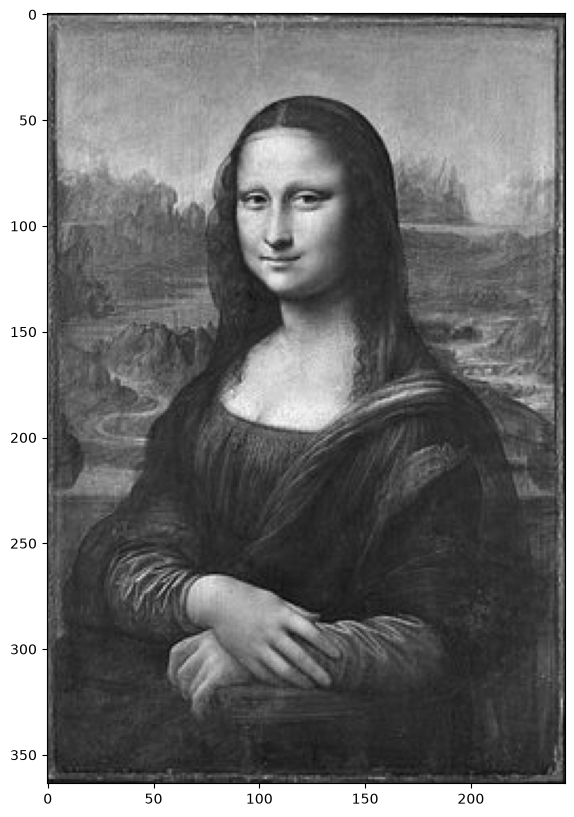

In [3]:
plt.imshow(img,cmap='gray')

A continuación, transformamos la imagen en una matriz de valores comprendidos entre 0 y 255 mediante la biblioteca numpy. Es importante saber que al cambiar el tipo de dato de imagen a matriz se cambian los ejes https://stackoverflow.com/questions/33725237/image-fromarray-changes-size. Llamamos IM2ARRAY a la matriz que guarda las intensidades de gris de los píxeles.

In [4]:
IM2ARRAY = np.array(img)

Podemos ver qué aspecto tiene

In [5]:
IM2ARRAY

array([[ 22,  47,  38, ...,  28,  34,  34],
       [ 87, 131,  97, ...,  26,  31,  20],
       [113, 117,  77, ...,  79,  79,  54],
       ...,
       [ 42, 102,  93, ...,  83,  77,  31],
       [ 16,  31,  17, ...,  69,  64,  31],
       [ 38,  33,  24, ...,  35,  35,  18]], shape=(364, 245), dtype=uint8)

Guardamos el tamaño de la matriz en la variable *im2array_shape* para poder crear otras matrices con el mismo tamaño.

In [6]:
im2array_shape = IM2ARRAY.shape

A continuación fijamos los parámetros del algoritmo genético para aproximar la imagen original mediante rectángulos en escala de grises.

In [7]:
# La longitud de los cromosomas
LONGITUD_CROMOSOMA = 150

# Tamaño de la población
TAMANO_POB = 500

# Número de cromosomas que intervienen en cada torneo
NUM_PARTICIPANTES = 50

# Probabilidad de mutación
PROB_MUTACION = 0.1

# Proporción de una generación que se usa como padres
PROP_PADRES = 0.5

# Número de generaciones
GENERACIONES = 10001

# Paso de impresión. Crearemos la imagen correspondiente al mejor cromosoma después de PASO_IMP generaciones
PASO_IMP = 100

### Ejercicio 1
Define la función GIO_genera_gen() que a partir de la variable *im2array_shape* devuelva una tupla $(x,y,dx,dy,c)$. Una vez fijado el extremo $(x,y)$ dentro del lienzo, debemos tener en cuenta que el rectángulo esté dentro del lienzo y que el color esté en el rango 0-255. 

In [10]:
# Solución
def GIO_genera_gen():
    x, y = random.randrange(im2array_shape[0]),random.randrange(im2array_shape[1])
    dx, dy = random.randrange(im2array_shape[0]-x), random.randrange(im2array_shape[1]-y)
    c = random.randrange(255)
    return (x,y,dx,dy,c) 


In [11]:
# Puedes probar la función
GIO_genera_gen()

# Posible respuesta:
# (185, 223, 49, 16, 2)

(302, 182, 9, 19, 223)

### Ejercicio 2
Define GIO_genera_cromosoma() que devuelva una tupla con tantos genes como determine el parámetro *LONGITUD_CROMOSOMA*

In [12]:
# Solución
def GIO_genera_cromosoma():
    return tuple(GIO_genera_gen() for _ in range(LONGITUD_CROMOSOMA))

In [13]:
# Ejemplo de uso. Guardamos el cromosoma generado en la variable ind_1
ind_1 = GIO_genera_cromosoma()
ind_1

# Posible respuesta:
# ((53, 10, 80, 200, 114),
#  (271, 209, 6, 4, 135),
#  ...
#  (310, 220, 35, 19, 174),
#  (264, 121, 37, 45, 200))

((169, 95, 173, 138, 26),
 (279, 27, 61, 122, 147),
 (98, 37, 102, 176, 101),
 (97, 50, 188, 89, 137),
 (273, 37, 43, 53, 179),
 (351, 59, 7, 96, 38),
 (59, 229, 236, 4, 163),
 (102, 138, 237, 20, 2),
 (38, 216, 106, 21, 233),
 (278, 174, 60, 14, 53),
 (350, 59, 0, 11, 239),
 (215, 38, 147, 77, 185),
 (203, 50, 134, 141, 46),
 (71, 211, 134, 11, 123),
 (85, 208, 109, 28, 131),
 (54, 31, 152, 67, 11),
 (25, 1, 191, 184, 185),
 (58, 242, 281, 0, 153),
 (324, 185, 9, 21, 2),
 (3, 151, 34, 77, 45),
 (177, 218, 179, 4, 222),
 (187, 21, 104, 102, 50),
 (23, 142, 147, 79, 128),
 (303, 129, 36, 52, 184),
 (2, 152, 33, 4, 230),
 (22, 36, 23, 189, 15),
 (85, 220, 248, 1, 218),
 (46, 141, 60, 67, 196),
 (138, 91, 4, 139, 179),
 (85, 81, 242, 46, 212),
 (247, 91, 87, 99, 195),
 (246, 61, 75, 112, 134),
 (156, 244, 200, 0, 31),
 (229, 18, 39, 1, 226),
 (158, 164, 120, 27, 224),
 (33, 225, 65, 1, 35),
 (243, 87, 28, 118, 243),
 (131, 51, 62, 157, 67),
 (198, 83, 121, 83, 95),
 (264, 190, 62, 52, 103

Cada gen representa un rectángulo dentro del lienzo y un cromosoma es una sucesión de genes. Para poder interpretar ese cromosoma como una imagen, primero generamos una matriz (array) a partir de ese conjunto de genes. En este caso, las posiciones que no están ocupadas por ningún cuadrado las interpretamos como blanco (valor 255) y en el resto de la posiciones se sumará la intensidad de los rectángulos que las ocupan. La función *GIO_decodifica* crea una matriz con la intensidad de gris de cada píxel a partir de un cromosoma.

In [14]:
def GIO_decodifica(ind):
    array_sal = np.zeros(im2array_shape,dtype='uint32')
    array_255 = np.full(im2array_shape,255,dtype='uint32')   
    for (x,y,dx,dy,c) in ind:
        array_sal[x:x+dx,y:y+dy]+= 255 - c
    mini = np.minimum(array_sal,array_255)
    inversa = 255 - mini
    return inversa

Podemos ver la matriz generada a partir del cromosoma que hemos creado.

In [15]:
matriz_1 = GIO_decodifica(ind_1)
print(matriz_1.tolist())

[[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255

Podemos ver la imagen correspondiente a ese cromosoma transformando la matriz en una imagen

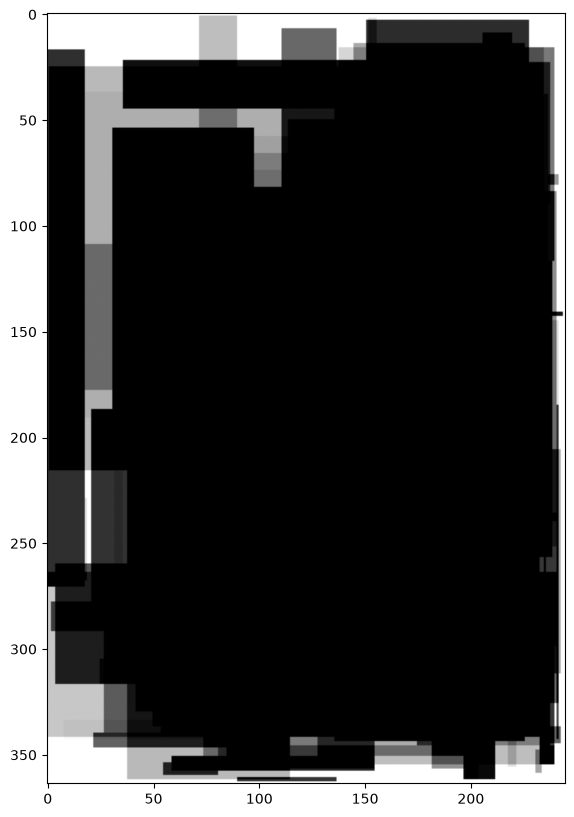

In [16]:
img_1 = Image.fromarray(matriz_1.astype('uint8'))
plt.imshow(img_1,cmap='gray')

Podemos ver una imagen junto a la otra

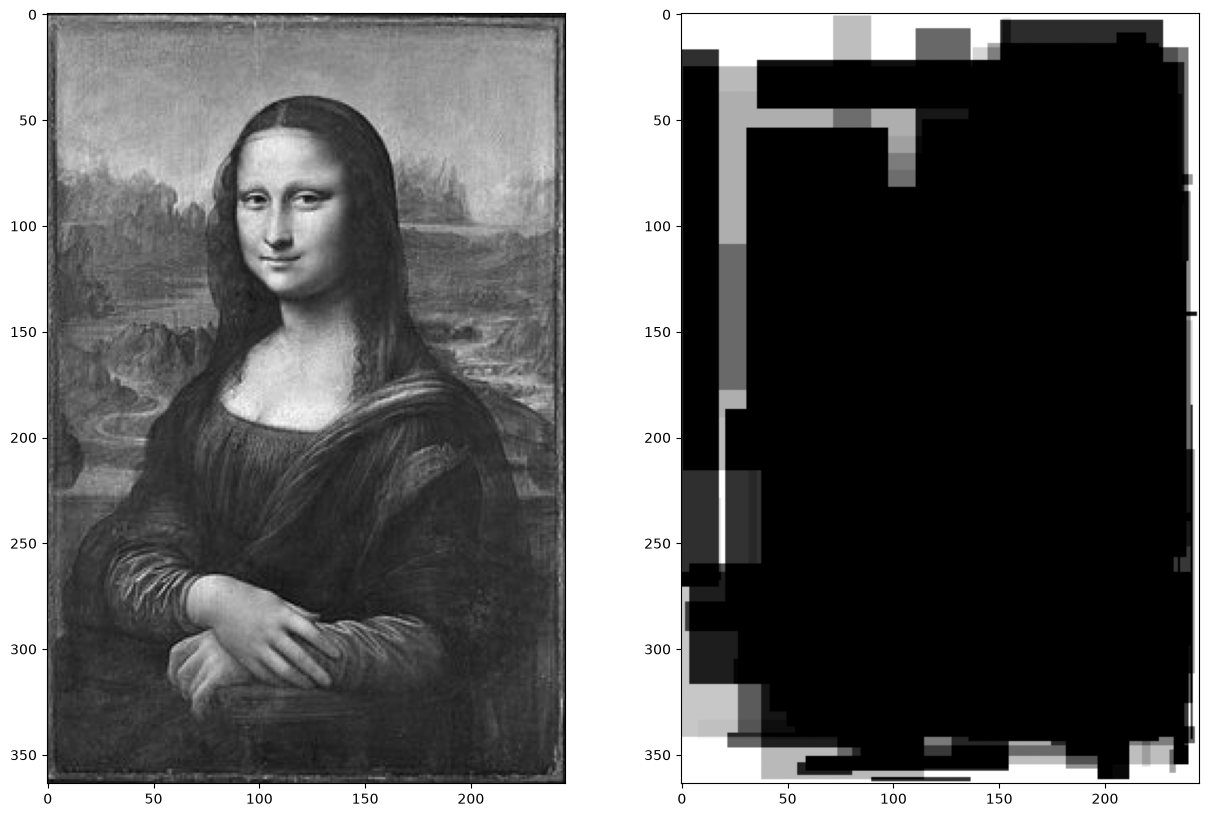

In [17]:
f, axarr = plt.subplots(1,2)
axarr[0].imshow(img,cmap='gray')
axarr[1].imshow(img_1,cmap='gray')

Obviamente, este cromosoma es una mala aproximación de la imagen original. Vamos a implementar un algoritmo genético que permita encontrar una mejor aproximación.

Para poder lanzar el algoritmo genético, en primer lugar definimos una función que nos permita crear una población inicial de cromosomas.

### Ejercicio 3
Define una función GIO_poblacion_inicial() que devuelva una lista con tantos cromosomas como determine la variable *TAMANO_POB*

In [18]:
# Solución
def poblacion_inicial():
    return [GIO_genera_gen() for _ in range(TAMANO_POB)]


Para poder seleccionar los mejores inidividuos de la población, necesitamos definir una función fitness. En este caso la función fitness se define como la suma de las diferencias (en valor absoluto) pixel a pixel entre la matriz que representa el cromosoma y la matriz que representa la imagen original.

In [19]:
def GIO_fitness(ind):
    return np.sum(np.absolute(GIO_decodifica(ind) - IM2ARRAY))

In [20]:
# Ejemplo:
GIO_fitness(ind_1)

np.uint64(329432577244447)

A continuación implementamos la selección por torneo. Para evitar repetir cálculos, cuando calculemos el fitness de un cromosoma, lo guardaremos en un diccionario y miraremos si ya ha sido calculado antes cuando necesitemos saber su valor. Las claves del diccionario serán los cromosomas y su valor, el valor de fitness que le corresponda.

### Ejercicio 4
Define la función *GIO_torneo(poblacion,dic)* que tome como entrada una población de cromosomas y un diccionario de pares *cromosoma:fitness* y devuelva una tupla *(seleccionado,nuevo_dic)* donde seleccionado sea un cromosoma de la población seleccionado por torneo con *NUM_PARTICIPANTES* como el número de participantes en cada torneo y *nuevo_dic* sea el diccionario *dic* al que se le han añadido los pares *cromosoma:fitness* que se hayan calculado en la búsqueda de *seleccionado*.

In [ ]:
# Solución


In [ ]:
# Ejemplo de uso
GIO_torneo(GIO_poblacion_inicial(),{})

### Ejercicio 5
Define la función *GIO_selecciona_torneo(poblacion,dic,n)* que además de la población y el diccionario del ejercicio anterior tome el número de cromosomas que queremos seleccionar. La salida debe ser una tupla *(seleccion,nuevo_dic)* donde *nuevo_dic* es el diccionario actualizado y seleccion una lista con los cromosomas seleccionados. 

In [ ]:
# Solución


In [ ]:
# Ejemplo de uso
GIO_selecciona_torneo(GIO_poblacion_inicial(),4,{})

A continuación definimos el cruce entre cromosomas

### Ejercicio 6
Define la función *cruza_padres(i1,i2)* que tome dos cromosomas y devuelva una lista con los dos hijos obtenidos mediante la técnica de cruce en un punto.

In [ ]:
# Solución


### Ejercicio 7
Define la función *cruza(padres)* que tome como entrada la lista *padres* con un número par de cromosomas y devuelva la lista de cromosomas obtenida aplicando la función *cruza_padres(i1,i2)* donde *i1* es un cromosoma que ocupa una posición de índice par e *i2* es el siguiente cromosoma.

In [ ]:
# Solución
   

En esta práctica consideraremos que la mutación de un cromosoma consiste en sustituir uno de sus genes por otro elegido aleatoriamente.

### Ejercicio 8
Define la función *muta_cromosoma(ind)* que reciba como entrada un cromosoma *ind* y que, con una probabilidad *PROB_MUTACION* cambie uno de sus genes por otro gen aleatorio.

In [ ]:
# Solución


### Ejercicio 9
Define una función *muta(poblacion)* que reciba como entrada la lista de cromosomas *poblacion* y aplique la función *muta_cromosoma* a cada uno de los cromosomas.

In [ ]:
# Solución


A continuación definimos el algoritmo que permite encontrar una nueva generación a partir de una dada.

### Ejercicio 10
Define una función *nueva_generacion(generacion,n_padres,n_directos,dic)* que reciba como entrada:
* *generacion* es una población de cromosomas
* *n_padres* es un número que determina cuántos cromosomas seleccionamos por torneo para ser padres
* *n_directos* es un número que determina cuántos cromosomas seleccionamos por torneo para pasar directamente a la siguiente generación.
* *dic* es un diccionario de pares *cromosoma:fitness*

La función debe seleccionar un conjunto de cromosomas para ser padres y otro para pasar directamente a la siguiente generación y a partir de los padres se debe genera un conjunto de hijos por cruce. La función debe devolver una tupla *(nueva_gen,nuevo_dic,)* donde *nueva_gen* es una lista de cromosomas formada por los cromosomas que han pasado directamente a la siguiente generación más el resultado de aplicar la función de mutación a los hijos.

In [ ]:
# Solución


Por último definimos el algoritmo genetico en el que se genera un a población inicial y se van creando nuevas generaciones usando las funciones anteriores. Además, cada *PASO_IMP* imprimimos la imagen correspondiente al mejor cromosoma. La función devuelve la lista de los valores *fitnes*  de estos cromosomas para poder luego representar gráficamente la evolución de la función a lo largo de las GENERACIONES.

In [ ]:
def algoritmo_genetico():
    poblacion= GIO_poblacion_inicial()
    dic = {}
    n_padres = round(TAMANO_POB * PROP_PADRES)
    n_padres = (n_padres if n_padres%2==0 else n_padres-1)
    n_directos = TAMANO_POB - n_padres
    mejores = []
    for counter in range(GENERACIONES):
        if counter%PASO_IMP == 0:
            print(counter)
            nuevo_dic = {}
            actual = 'inicial'
            min = float('inf')
            for ind in poblacion:
                f_ind = fitness(ind)
                nuevo_dic[ind] = f_ind
                if f_ind < min:
                    actual = ind
                    min = f_ind
            img_mejor = GIO_decodifica(actual).astype('uint8')
            imageio.imwrite('ga_{:>08}.jpg'.format(counter//PASO_IMP),img_mejor)
            mejores.append(min)
            poblacion, dic = nueva_generacion(poblacion,n_padres,n_directos,dic)
        else:
            poblacion, dic = nueva_generacion(poblacion,n_padres,n_directos,dic)
            print('.',end='')
    return mejores

In [ ]:
sal_ag = algoritmo_genetico()

In [ ]:
plt.plot(sal_ag[1:])
plt.show()